  CHỦ ĐỀ 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ (EDA) KẾ TOÁN 
Xử lý dữ liệu trống hoàn tất!
    Ma_DN  X1_ThanhToanHienThoi  X2_TyLeNo    X3_ROA  X4_VongQuayTonKho  \
0  DN_001              2.051894   0.157646 -0.048719           4.212880   
1  DN_002              3.340888   0.713156 -0.085632           5.749597   
2  DN_003              2.796379   0.203367  0.198291           6.344409   
3  DN_004              1.347188   0.788131  0.125096           3.920486   
4  DN_005              1.163136   0.894573  0.002081           8.670997   

   Trang_Thai_KietQue  
0                   0  
1                   1  
2                   0  
3                   0  
4                   0  


C:\Users\Admin\AppData\Local\Temp\ipykernel_1464\1223168302.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_accounting['X3_ROA'].fillna(roa_median, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_1464\1223168302.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_accounting, x='Trang_Thai_KietQue', y='X2_TyLeNo', ax=axes[0], palette='Oranges')
C:\Users

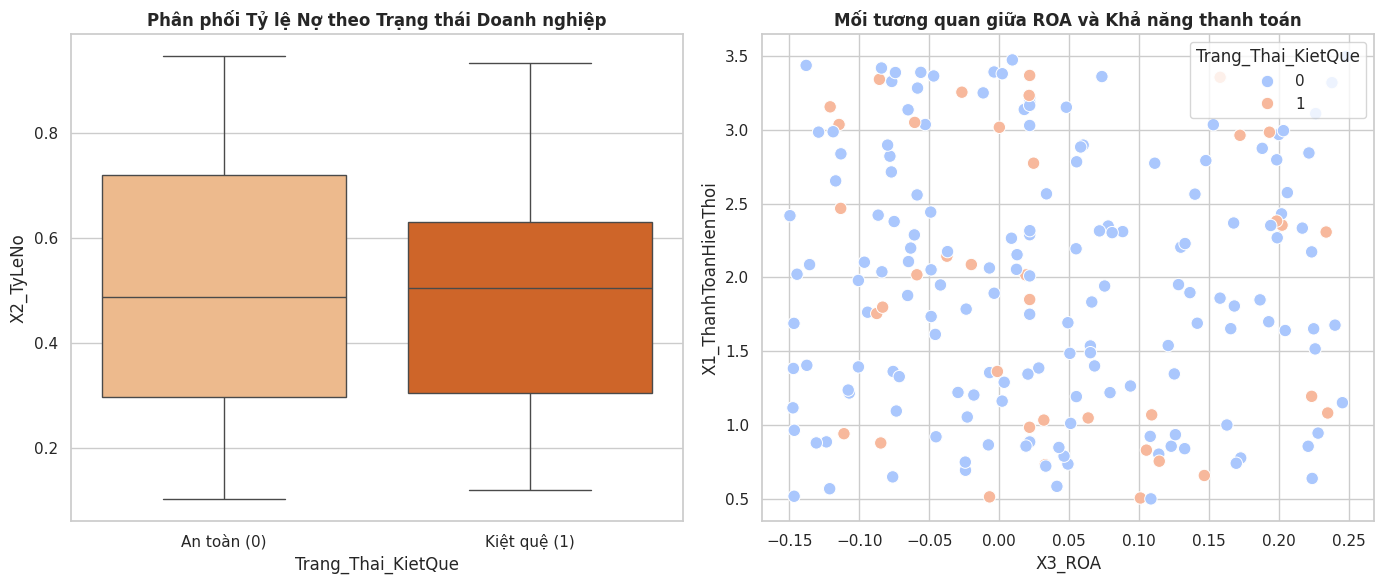

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đồ họa hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("======================================================================")
print("  CHỦ ĐỀ 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ (EDA) KẾ TOÁN ")
print("======================================================================")

# 1. KHỞI TẠO TẬP DỮ LIỆU CHỈ SỐ KẾ TOÁN (200 Doanh nghiệp)
np.random.seed(23)
n_companies = 200

accounting_data = {
    'Ma_DN': [f'DN_{i:03d}' for i in range(1, n_companies + 1)],
    'X1_ThanhToanHienThoi': np.random.uniform(0.5, 3.5, n_companies),
    'X2_TyLeNo': np.random.uniform(0.1, 0.95, n_companies),
    'X3_ROA': np.random.uniform(-0.15, 0.25, n_companies),
    'X4_VongQuayTonKho': np.random.uniform(1.5, 12.0, n_companies),
    'Trang_Thai_KietQue': np.random.choice([0, 1], size=n_companies, p=[0.82, 0.18])
}

df_accounting = pd.DataFrame(accounting_data)
df_accounting.loc[np.random.choice(df_accounting.index, 12), 'X3_ROA'] = np.nan

# 2. TIỀN XỬ LÝ DỮ LIỆU KẾ TOÁN
roa_median = df_accounting['X3_ROA'].median()
df_accounting['X3_ROA'].fillna(roa_median, inplace=True)

print("Xử lý dữ liệu trống hoàn tất!")
print(df_accounting.head())

# 3. VẼ GRAPH PHÂN TÍCH
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Đồ thị 1: Boxplot Tỷ lệ Nợ
sns.boxplot(data=df_accounting, x='Trang_Thai_KietQue', y='X2_TyLeNo', ax=axes[0], palette='Oranges')
axes[0].set_title('Phân phối Tỷ lệ Nợ theo Trạng thái Doanh nghiệp', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['An toàn (0)', 'Kiệt quệ (1)'])

# Đồ thị 2: Scatter Plot ROA vs Thanh Toán
sns.scatterplot(data=df_accounting, x='X3_ROA', y='X1_ThanhToanHienThoi', hue='Trang_Thai_KietQue', palette='coolwarm', s=80, ax=axes[1])
axes[1].set_title('Mối tương quan giữa ROA và Khả năng thanh toán', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()